# PREDICTIVE MAINTENANCE (MACHINE FAILURE PREDICTION) - EDA ANALYSIS

In [1]:
import pandas as pd
dataset_original=pd.read_csv("ai4i2020_original.csv") #copy of original dataset
dataset = dataset_original
dataset_original.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


# Descriptive analysis

## Univariate_analysis

### quan qual

In [2]:
from Univariate_analysis import Univariate
Univariate = Univariate(dataset)
quan, qual = Univariate.quanQual()
print(f"quan cols :\n {quan} and\n\n qual col: {qual}")

quan cols :
 ['UDI', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'] and

 qual col: ['Product ID', 'Type']


### frequency

In [3]:
freq_table={}
for column in quan:
    freq_table[column] = Univariate.freqTable(column)
freq_table

{'UDI':       Unique_values  Frequency  Relative_frequency  Cumsum
 0                 1          1              0.0001  0.0001
 1              6671          1              0.0001  0.0002
 2              6664          1              0.0001  0.0003
 3              6665          1              0.0001  0.0004
 4              6666          1              0.0001  0.0005
 ...             ...        ...                 ...     ...
 9995           3334          1              0.0001  0.9996
 9996           3335          1              0.0001  0.9997
 9997           3336          1              0.0001  0.9998
 9998           3337          1              0.0001  0.9999
 9999          10000          1              0.0001  1.0000
 
 [10000 rows x 4 columns],
 'Air temperature [K]':     Unique_values  Frequency  Relative_frequency      Cumsum
 0           300.7        279            3.000000    3.000000
 1           298.9        231            2.483871    5.483871
 2           297.4        230      

### Univariate - descriptive analysis 

In [4]:
# quan_inputcols = dataset[quan].drop('Machine failure',axis=1)  #Skip outlier detection for binary target variables.
descriptive_analysis = Univariate.univariate_continuous(quan)
'''
Median - threshold of input features 
'''
descriptive_analysis

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
Mean,5000.5,300.00493,310.00556,1538.7761,39.98691,107.951,0.0339,0.0046,0.0115,0.0095,0.0098,0.0019
Median,5000.5,300.1,310.1,1503.0,40.1,108.0,0.0,0.0,0.0,0.0,0.0,0.0
Mode,1,300.7,310.6,1452,40.2,0,0,0,0,0,0,0
Q1:25%,2500.75,298.3,308.8,1423.0,33.2,53.0,0.0,0.0,0.0,0.0,0.0,0.0
Q2:50%,5000.5,300.1,310.1,1503.0,40.1,108.0,0.0,0.0,0.0,0.0,0.0,0.0
Q3:75%,7500.25,301.5,311.1,1612.0,46.8,162.0,0.0,0.0,0.0,0.0,0.0,0.0
99%,9900.01,304.1,313.2,2188.01,62.8,222.0,1.0,0.0,1.0,0.0,0.0,0.0
Q4:100%,10000.0,304.5,313.8,2886.0,76.6,253.0,1.0,1.0,1.0,1.0,1.0,1.0
IQR,4999.5,3.2,2.3,189.0,13.6,109.0,0.0,0.0,0.0,0.0,0.0,0.0
1.5_rule,7499.25,4.8,3.45,283.5,20.4,163.5,0.0,0.0,0.0,0.0,0.0,0.0


### find_outlier

In [5]:
least_outlier, greater_outlier = Univariate.find_outlier(descriptive_analysis,quan)
print(f"least_outlier : {least_outlier} and\ngreater_outlier: {greater_outlier}")

least_outlier : ['Torque [Nm]'] and
greater_outlier: ['Rotational speed [rpm]', 'Torque [Nm]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


### Replace_outlier

In [6]:
# new_da, data = Univariate.replace_outlier(descriptive_analysis,quan)


In [7]:
# check outliers
# least_outlier, greater_outlier = Univariate.find_outlier(new_da,quan)
# print(f"least_outlier : {least_outlier} and\ngreater_outlier: {greater_outlier}")

In [8]:
# import seaborn as sns
# sns.pairplot(dataset[quan])   #visual graph after removing outliers 

''' NOTE:

KEEPING OUTLIERS EXACTLY AS HOW THEY ARE

In a "normal" data science project (like predicting house prices), an outlier is often an error. In Predictive Maintenance, an outlier is a signal.

I performed an outlier analysis on the sensor telemetry. While several features (Torque, RPM) contained statistical outliers,
I chose to retain them because, in a predictive maintenance context, these anomalies represent critical failure modes. 
To ensure model stability


THESE OUTLIERS ==> HANDLED USING RobustScaler (without capping) - STANDARDIZATION 

'''

## Bivariate analysis

### covariance & correlation 

In [9]:
cov_matrix = dataset[['Air temperature [K]'	,'Process temperature [K]',	'Rotational speed [rpm]'	,'Torque [Nm]'	,'Tool wear [min]']].cov()
cov_matrix

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Air temperature [K],4.001035,2.600157,8.129957,-0.274736,1.763808
Process temperature [K],2.600157,2.201467,5.127798,-0.207974,1.273840
Rotational speed [rpm],8.129957,5.127798,32142.787047,-1563.910772,2.545883
Torque [Nm],-0.274736,-0.207974,-1563.910772,99.379640,-1.962568
Tool wear [min],1.763808,1.273840,2.545883,-1.962568,4051.850384


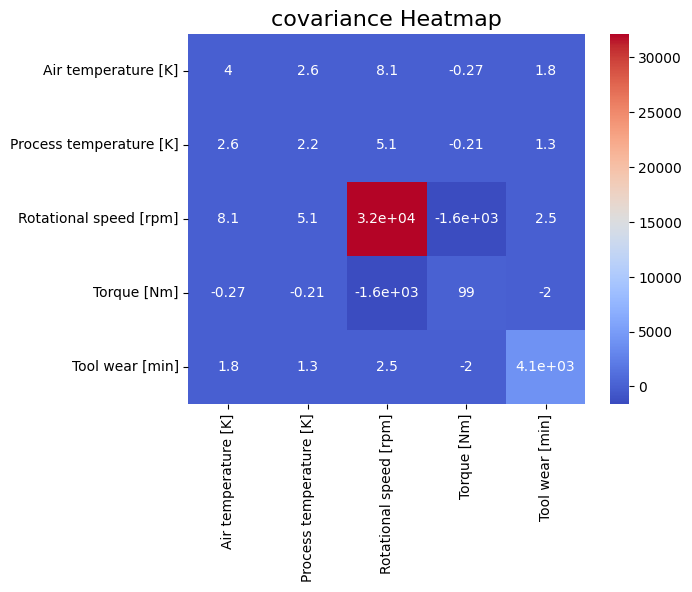

In [10]:
import seaborn as sns 
import matplotlib.pyplot as plt
sns.heatmap(cov_matrix,annot=True,cmap='coolwarm')
plt.title("covariance Heatmap", fontsize=16)
plt.show()

In [11]:
correlation_matrix = dataset[['Air temperature [K]'	,'Process temperature [K]',	'Rotational speed [rpm]'	,'Torque [Nm]'	,'Tool wear [min]']].corr()
correlation_matrix

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Air temperature [K],1.000000,0.876107,0.022670,-0.013778,0.013853
Process temperature [K],0.876107,1.000000,0.019277,-0.014061,0.013488
Rotational speed [rpm],0.022670,0.019277,1.000000,-0.875027,0.000223
Torque [Nm],-0.013778,-0.014061,-0.875027,1.000000,-0.003093
Tool wear [min],0.013853,0.013488,0.000223,-0.003093,1.000000


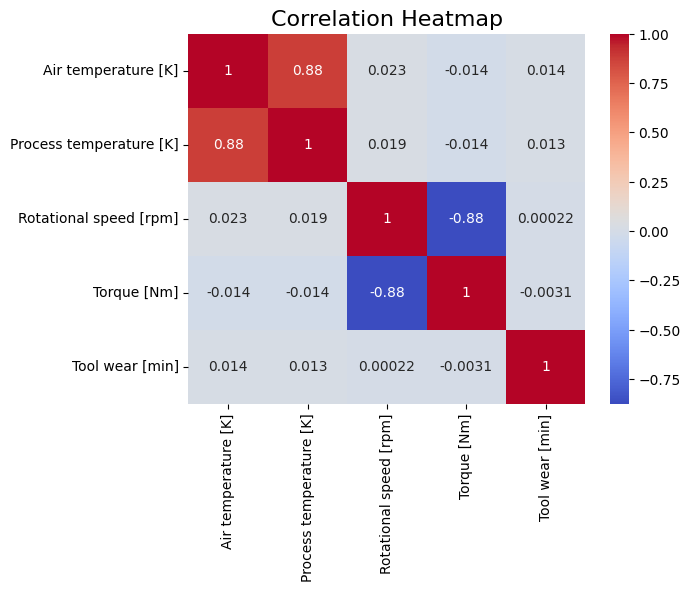

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

### Multicolinearity analysis using VIF

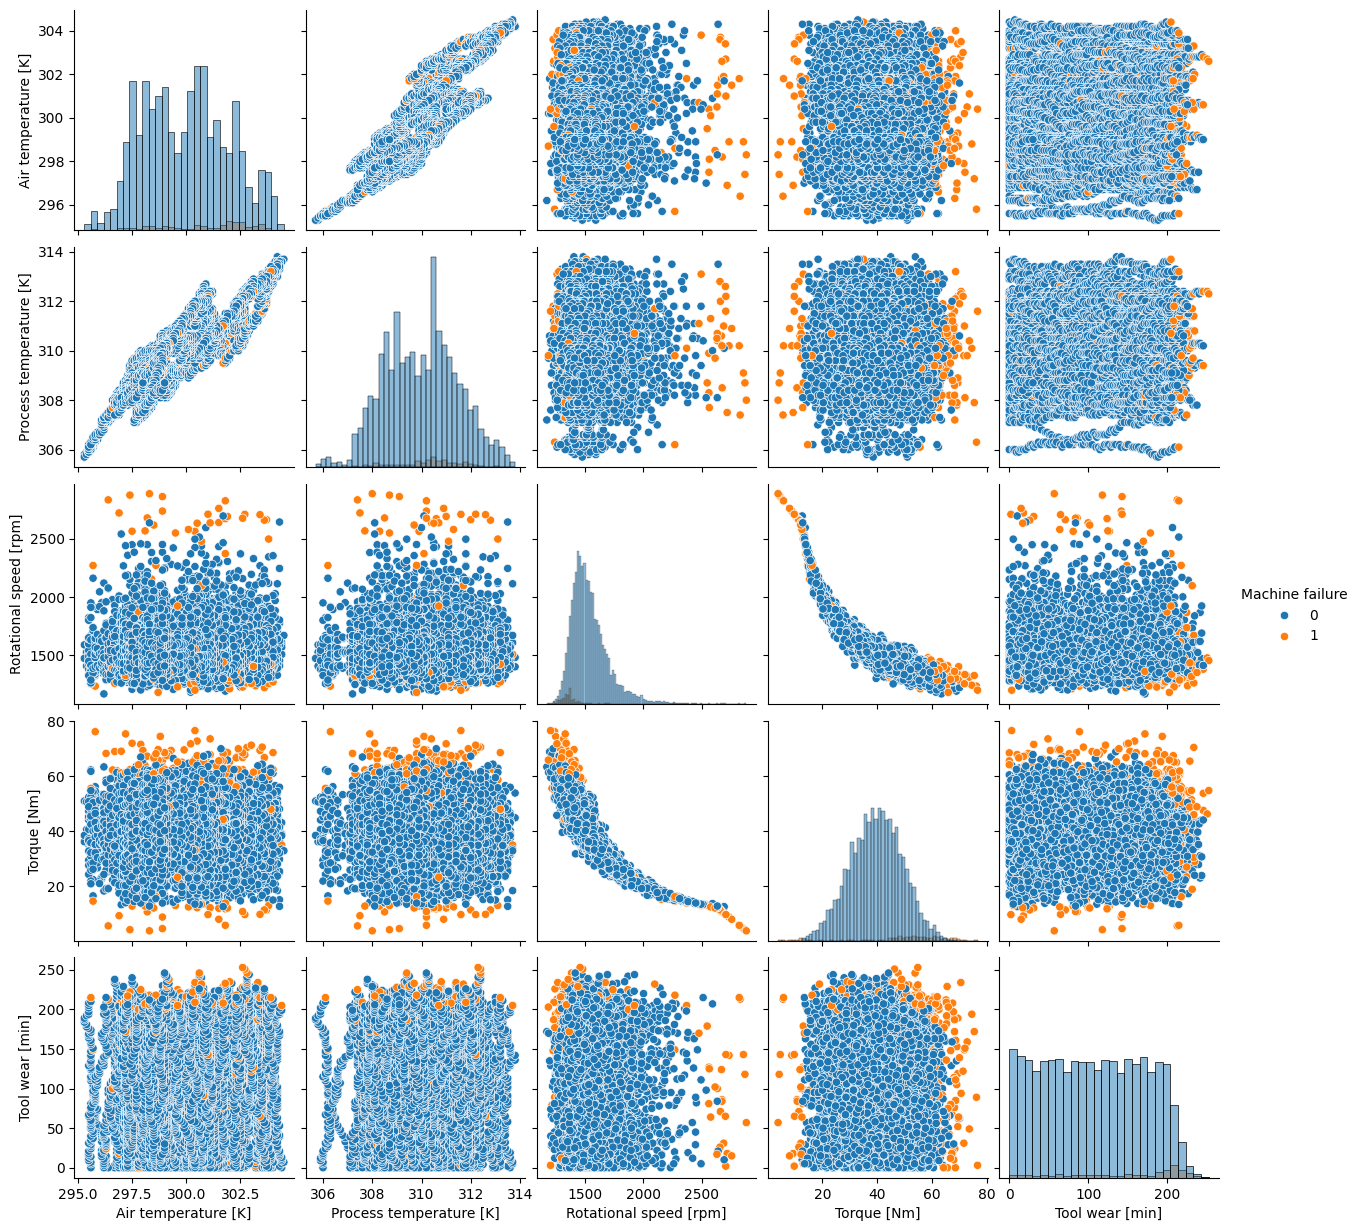

In [13]:
sample_data = dataset.drop(['Product ID','UDI','TWF', 'HDF', 'PWF', 'OSF', 'RNF'],axis=1)
sns.pairplot(sample_data,hue='Machine failure',diag_kind='hist')

In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
def calc_vif(dataset):
     vif = pd.DataFrame()
     vif["variables"]=dataset.columns
     vif["VIF"]=[variance_inflation_factor(dataset.values ,col_index)  for col_index in range(len(dataset.columns))]
     return vif

'''
variance_inflation_factor(ndarray, column_index_int)
'''

calc_vif(dataset[['Air temperature [K]'	,'Process temperature [K]',	'Rotational speed [rpm]'	,'Torque [Nm]'	,'Tool wear [min]']])

,variables,VIF
0,Air temperature [K],87413.106376
1,Process temperature [K],88285.242860
2,Rotational speed [rpm],315.329872
3,Torque [Nm],72.125192
4,Tool wear [min],3.877244


## KEY NOTE: DESCRIPTIVE ANALYSIS 

 KEY NOTE: DESCRIPTIVE ANALYSIS

I performed exploratory data analysis by first separating the features into quantitative and qualitative variables. I analyzed the frequency distribution of numerical features and observed that air temperature values are concentrated around 300 K, process temperature around 310 K, rotational speed around 1500 RPM, torque around the 30–40 range, and tool wear shows repeated values in certain ranges. The target variable, machine failure, is binary with values 0 and 1. I then examined central tendency measures such as mean, median, and mode. Most features showed similar mean and median values, indicating relatively symmetric distributions, whereas rotational speed and torque showed slight differences between mean and median, suggesting the presence of outliers. Using percentile analysis and the interquartile range (IQR), I confirmed that rotational speed and torque contain notable outliers. Further, skewness analysis showed that rotational speed is positively skewed (around 1.9), while other features are close to symmetric. Kurtosis analysis indicated that rotational speed is highly leptokurtic (around 7.3), meaning it has heavy tails and more extreme outliers, whereas some features showed platykurtic behavior, indicating fewer outliers.

I also analyzed relationships between variables using covariance and correlation. Air temperature and process temperature showed a strong positive correlation (around 0.88), while rotational speed and torque exhibited a strong negative correlation (around -0.88). To further validate multicollinearity, I calculated the Variance Inflation Factor (VIF), where air and process temperature showed extremely high VIF values, indicating severe multicollinearity. Rotational speed and torque also showed high VIF values, confirming a linear dependency. This suggests that some features may need to be removed or handled carefully during model building to avoid multicollinearity issues. As a next step, I plan to perform influence analysis to understand the impact of extreme observations.


# Inferential analysis

## A. Descriptive Analysis
### What is the overall failure rate?

In [15]:
freq_table = Univariate.freqTable('Machine failure')
freq_table

,Unique_values,Frequency,Relative_frequency,Cumsum
0,0,9661,4830.5,4830.5
1,1,339,169.5,5000.0


### Which failure type is most common?

In [16]:
failure_modes = ['TWF', 'HDF', 'PWF', 'OSF','RNF']
failure_count = {col: dataset_original[col].sum() for col in failure_modes } 
failure_count
sort_failure_modes = sorted(failure_count.items(), key=lambda x: x[1],reverse=True)   # key condition tells -> sort by values , reverse -> descending order

for failure_modes, counts in sort_failure_modes:
    print(failure_modes ," : ",counts)
most_common_failure =sort_failure_modes[0]
print(f"\n{most_common_failure[0]} is the most common failure type with {most_common_failure[1]} counts")

HDF  :  115
OSF  :  98
PWF  :  95
TWF  :  46
RNF  :  19

HDF is the most common failure type with 115 counts


In [17]:
# for i in failure_counts.items():
#     print(i[1])
# failure_counts.items()

### Which product type has the highest failure rate?

In [18]:
# USING AND pandas 
failure_rate = dataset.groupby('Type')['Machine failure'].mean()
product_quality = failure_rate.idxmax()   #using idxmax() to get the label
rate = failure_rate.sort_values(ascending=False).iloc[0]
print(f'{product_quality} : {rate}-> product type has the highest failure rate')

L : 0.03916666666666667-> product type has the highest failure rate


<Axes: xlabel='Machine failure', ylabel='Type'>

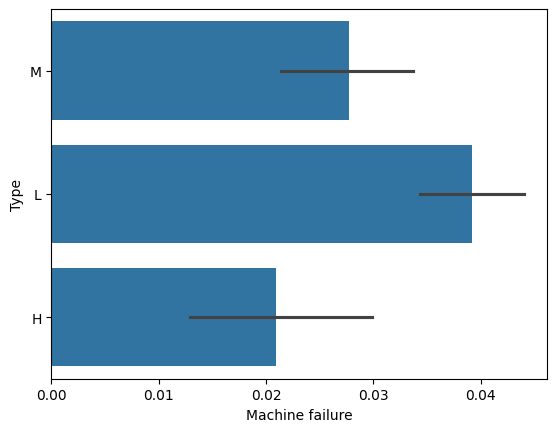

In [19]:
import seaborn as sns 
sns.barplot(y="Type", x="Machine failure", data=dataset)

## B. Statistical Analysis / Hypothesis Testing
### Is there a significant difference in input features between failed and non-failed machines? 
#### ---> tells machine failure cases has any impact from the input features

In [20]:
from scipy.stats import ttest_ind   
input_features = ['Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
for column in input_features:
    nonfailed_machine=dataset[dataset['Machine failure']==0][column]
    failed_machine=dataset[dataset['Machine failure']==1][column]
    # print("pvalue=3.976075962869404e-26  --> there is significant difference in nonfailed_machine -Tool wear [min] and failed_machine -Tool wear [min] ")
    stats, pvalue = ttest_ind(nonfailed_machine,failed_machine)
    print("\n", ttest_ind(nonfailed_machine,failed_machine))
    if pvalue < 0.05:
        print('there is significant difference in features & Machine failure/non failure-- ', column)
    else:
        print('there is no significant difference in features & Machine failure/non failure -- ', column)


 TtestResult(statistic=-3.5965621887156423, pvalue=0.00032400575504099347, df=9998.0)
there is significant difference in features & Machine failure/non failure--  Process temperature [K]

 TtestResult(statistic=4.4226338711502375, pvalue=9.853543100511278e-06, df=9998.0)
there is significant difference in features & Machine failure/non failure--  Rotational speed [rpm]

 TtestResult(statistic=-19.49019557161729, pvalue=4.573804886191649e-83, df=9998.0)
there is significant difference in features & Machine failure/non failure--  Torque [Nm]

 TtestResult(statistic=-10.602880588762876, pvalue=3.976075962869404e-26, df=9998.0)
there is significant difference in features & Machine failure/non failure--  Tool wear [min]


In [21]:
import scipy.stats as stats
stats.f_oneway(dataset['Air temperature [K]'], dataset['Process temperature [K]'],dataset['Rotational speed [rpm]'],dataset['Torque [Nm]'],dataset['Tool wear [min]'])

F_onewayResult(statistic=520727.5584553578, pvalue=0.0)

p- value = 0.0    >  0.05    =>  reject H1 accept H0

there is significant difference in these above features 

### Is there a significant association between product quality (L, M, H) and machine failure?
#### ---> tells does machine failure cases, most impacted based on any specific product quality

In [22]:
import scipy.stats 
L_indication=dataset[dataset['Type']=='L']['Machine failure']
M_indication=dataset[dataset['Type']=='M']['Machine failure']
H_indication=dataset[dataset['Type']=='H']['Machine failure']
print("pvalue=0.001029660332824345  --> there is significant difference  ")
print(scipy.stats.f_oneway(L_indication,M_indication,H_indication))

'''certain product types fail more than others (Significant association).'''

pvalue=0.001029660332824345  --> there is significant difference  
F_onewayResult(statistic=6.883261309073376, pvalue=0.001029660332824345)


'certain product types fail more than others (Significant association).'

In [23]:
# H_indication.value_counts()

### Is there a significant difference between product quality (L, M, H) for each numerical feature: process temperature, rotational speed, torque, tool wear? (ANOVA )
#### -->  tells does product quality impacts input feature values

In [24]:
import scipy.stats 
input_features = ['Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
for col in input_features:
    L_group=dataset[dataset['Type']=='L'][col]
    M_group=dataset[dataset['Type']=='M'][col]
    H_group=dataset[dataset['Type']=='H'][col]
    fstat, pvalue = scipy.stats.f_oneway(L_group,M_group,H_group)
    print("pvalue: ",pvalue)
    if pvalue < 0.05:
        print('there is significant difference in features & product quality -- ', col)
    else:
        print('there is no significant difference in features & product quality -- ', col)

'''
The Conclusion: If the sensors behave the same for all types, but L fails more often, it suggests that L-type parts are physically weaker and break under the same stress that an H-type part survives. This makes the Type feature extremely important for your model to distinguish between a "safe" load and a "breaking" load.
'''

pvalue:  0.1953596091414614
there is no significant difference in features & product quality --  Process temperature [K]
pvalue:  0.8908522559027826
there is no significant difference in features & product quality --  Rotational speed [rpm]
pvalue:  0.879712060668968
there is no significant difference in features & product quality --  Torque [Nm]
pvalue:  0.7112218755388934
there is no significant difference in features & product quality --  Tool wear [min]


'\nThe Conclusion: If the sensors behave the same for all types, but L fails more often, it suggests that L-type parts are physically weaker and break under the same stress that an H-type part survives. This makes the Type feature extremely important for your model to distinguish between a "safe" load and a "breaking" load.\n'


## C. Root Cause / Risk Analysis
### Which input parameter has the strongest impact on failure?


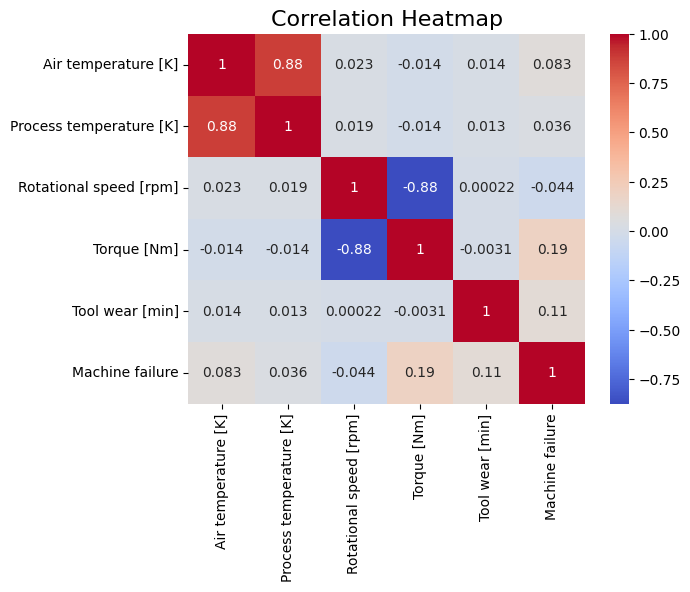

Rotational speed [rpm]    -0.044188
Process temperature [K]    0.035946
Air temperature [K]        0.082556
Tool wear [min]            0.105448
Torque [Nm]                0.191321
Machine failure            1.000000
Name: Machine failure, dtype: float64
Torque [Nm]  - 0.191321  --> input parameter has the strongest impact on failure


'The highest absolute correlation (0.191) is for Torque [Nm], so it is indeed the most influential input parameter in your dataset.'

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
sample_data = dataset.drop(['Product ID','UDI','TWF', 'HDF', 'PWF', 'OSF', 'Type','RNF'],axis=1)
correlation_matrix=sample_data.corr()
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

print(correlation_matrix['Machine failure'].sort_values())

print("Torque [Nm]  - 0.191321" , " --> input parameter has the strongest impact on failure")
'''The highest absolute correlation (0.191) is for Torque [Nm], so it is indeed the most influential input parameter in your dataset.'''

### Are failures happening at extreme values?


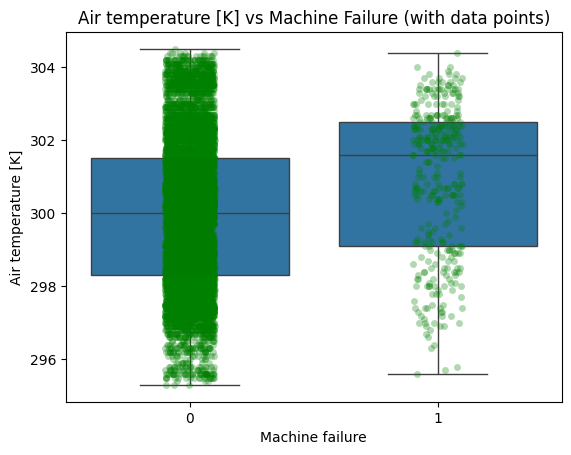

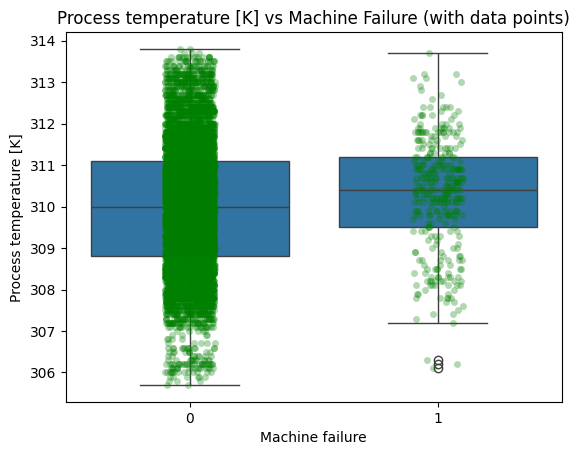

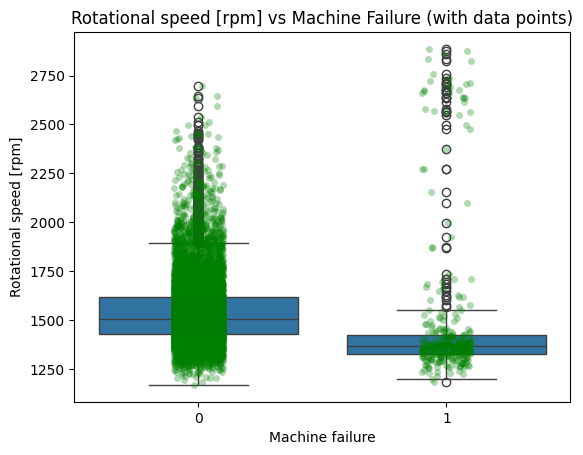

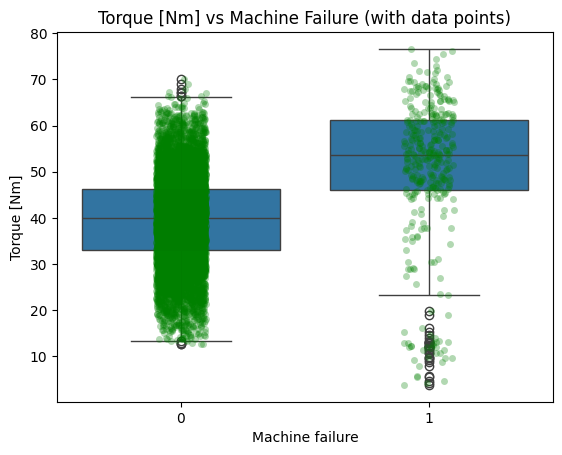

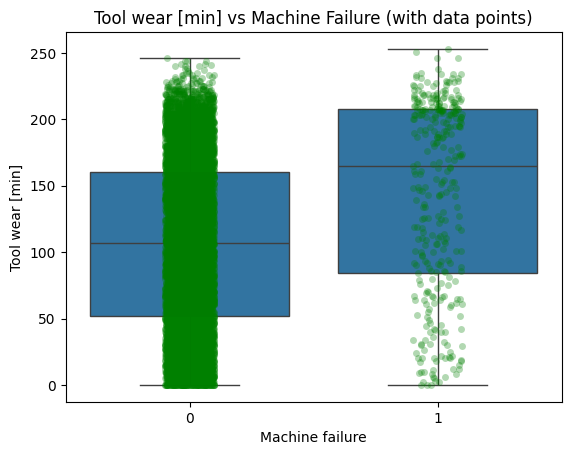

' yes extreme values in features like Rotational speed and torque affect the machine failure '

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
input_features = ['Air temperature [K]','Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
for col in input_features:
    sns.boxplot(data=dataset, x='Machine failure' ,y=col )
    sns.stripplot(x='Machine failure', y=col, data=dataset, color='green', alpha=0.3)
    plt.title(f'{col} vs Machine Failure (with data points)')
    plt.show()

''' yes extreme values in features like Rotational speed and torque affect the machine failure '''

In [27]:
dataset.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

### Are certain combinations risky? (e.g., high torque + low speed)

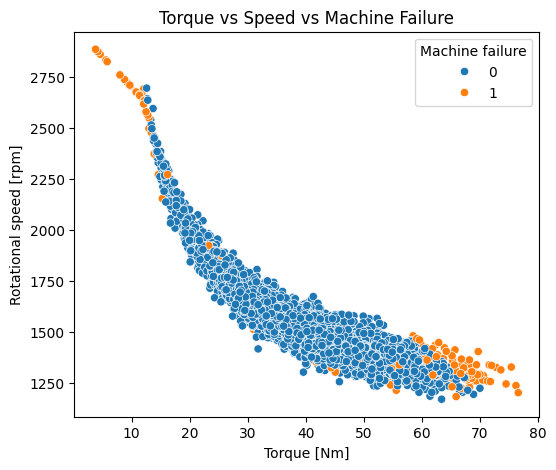

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.scatterplot(
    x='Torque [Nm]',
    y='Rotational speed [rpm]',
    hue='Machine failure',
    data=dataset
)
# 0- machine non failure ,    1- machine failure
plt.title('Torque vs Speed vs Machine Failure')
plt.show()

“Failures are concentrated in extreme operating conditions. Specifically, high torque combined with low rotational speed shows a higher density of failures, indicating mechanical overload conditions. Additionally, some failures occur at very low torque and high speed, suggesting instability at extreme operating limits.”

High Torque + Low Speed

→ Heavy load → stress → failure  (main risk)

Low Torque + High Speed

→ Possible vibration / imbalance → failure  (secondary risk)

## D. Recommendations / Actionable Insights
### Are there critical thresholds for failure?
#### - beyond this conditions lead to the highest failure risk

In [29]:
import pandas as pd
input_features = ['Air temperature [K]','Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
threshold={}
percentail=[0.25,0.50,0.75]

for feature in input_features:
    threshold[feature]={}     # each feature percentail calculation 
    for p in percentail:
        threah_value = dataset[feature].quantile(p)   # find percentail

        # check the correlation b/w feature & machine failure 
        if dataset[feature].corr(dataset['Machine failure']) > 0 : 
            high_risk = dataset[dataset[feature]>threah_value]   # high value-> high risk 
        else:
            high_risk = dataset[dataset[feature]<threah_value]    # low value -> low risk 

        # mean of high risk data for each feature
        failure_rate=high_risk['Machine failure'].mean()
        threshold[feature][f'{int(p*100)}%']=round(failure_rate,3)

threshold_analysis = pd.DataFrame(threshold)
threshold_analysis

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
25%,0.038,0.037,0.103,0.039,0.038
50%,0.047,0.044,0.056,0.056,0.045
75%,0.070,0.039,0.039,0.099,0.069


Air temperature [K]	 > 75th percentile → failure rate = 0.07 → moderate threshold
Process temperature [K] > 50th percentile → failure rate = 0.044 → minor threshold
Rotational speed [rpm] < 25th percentile → failure rate = 0.103 → critical threshold
Torque [Nm] > 75th percentile → failure rate = 0.099 → critical threshold
Tool wear [min] > 75th percentile → failure rate = 0.069 → moderate threshold

Critical thresholds were identified using percentile-based segmentation. Torque above the 75th percentile and rotational speed below the 25th percentile showed the highest failure rates, indicating key risk zones. Tool wear and air temperature showed moderate impact, while process temperature had minimal influence.

### Can we define a safe operating range?
#### - Operating within safe thresholds reduces failure probability to ~0.5%

In [30]:
safe_condition = (
    (dataset['Torque [Nm]'] <= dataset['Torque [Nm]'].quantile(0.75)) &
    (dataset['Rotational speed [rpm]'] >= dataset['Rotational speed [rpm]'].quantile(0.25)) &
    (dataset['Tool wear [min]'] <= dataset['Tool wear [min]'].quantile(0.75)) & 
    (dataset['Air temperature [K]'] <= dataset['Air temperature [K]'].quantile(0.75))& 
    (dataset['Process temperature [K]'] <= dataset['Process temperature [K]'].quantile(0.50))
)

dataset['Safe Zone'] = safe_condition

# Validate
print('failure rate in safe zone : \n',dataset.groupby('Safe Zone')['Machine failure'].mean())

failure rate in safe zone : 
 Safe Zone
False    0.044245
True     0.004939
Name: Machine failure, dtype: float64


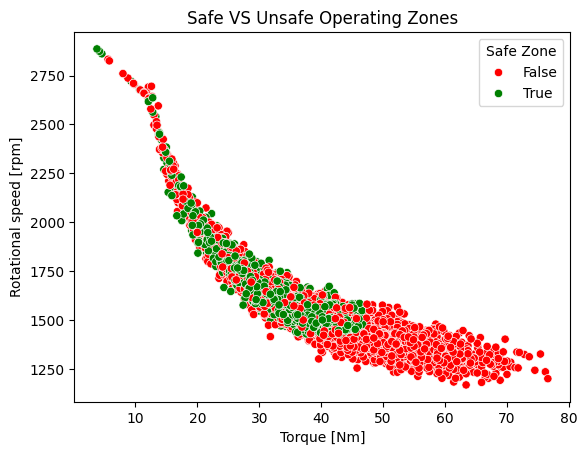

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(
    x='Torque [Nm]', 
    y='Rotational speed [rpm]', 
    hue='Safe Zone',
    data=dataset,
    palette={True:'green',False:'red'}
             )
plt.title('Safe VS Unsafe Operating Zones')
plt.show()

### Which product type is most reliable?

In [32]:
reliable = dataset.groupby('Type')['Machine failure'].mean()
print('High quality product type is most reliable \n', reliable)

High quality product type is most reliable 
 Type
H    0.020937
L    0.039167
M    0.027694
Name: Machine failure, dtype: float64


EDA and Predictive Maintenance Analysis Summary

1. Descriptive Analysis

I started with a descriptive analysis to understand the overall dataset.
The dataset is highly imbalanced: there are 9,661 non-failure instances and 339 failure instances.
Among failure types, the most common is HDF (Heat dissipation Failure), followed by Overstrain, Power Failure, Tool Wear, and other random types.

2. Product Type and Failure Rate

I analyzed the effect of product type on machine failure.
It was observed that low-quality products have the highest failure rates, indicating that product quality significantly influences failures.

3. Statistical and Hypothesis Testing (Inferential Analysis)

I compared input features across machine failure and non-failure cases.
Significant differences were observed in all input features between failed and non-failed machines.
I also analyzed the relationship between product quality and machine failure, finding a statistically significant difference.
However, when checking input features across product quality levels, no significant differences were found.

4. Root Cause and Risk Analysis

To identify which input parameters have the strongest impact on failure, I created a correlation heatmap. Torque emerged as the most influential parameter.
Using boxplots, I observed that failures often occur at extreme values of rotational speed and torque.
For risky combinations, scatterplots revealed that high torque + low speed or low torque + high speed conditions are associated with failures. These combinations represent the primary mechanical risk scenarios.

5. Recommendations and Actionable Insights

I calculated critical thresholds for input features using percentiles (25th, 50th, 75th) and assessed their correlation with machine failure.
Identified a safe operating range where machine failure probability is extremely low (~0.04%), ensuring operational reliability.
Grouping by product type, high-quality products were found to be the most reliable.

6. Summary

Failures are rare but mostly occur in low-quality products and at extreme machine parameters.
Torque is the most critical parameter impacting failure.
High torque + low speed is the riskiest condition.
Safe operating thresholds have been identified to minimize risk.